In [1]:
!pip install mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 86.5 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.0/814.0 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.4 MB/s eta 0:00:00
  Attempting uninstall: dacite
    Fo

In [2]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.tensorflow

from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

2026-03-07 02:46:31.470856: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772851591.660043      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772851591.709993      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772851592.149643      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772851592.149686      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772851592.149689      55 computation_placer.cc:177] computation placer alr

In [3]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("dagshub_token")

In [4]:
DAGSHUB_USERNAME = "Aryanupadhyay23"
DAGSHUB_REPO = "Emotion-Detection-Deep-Learning"

MLFLOW_TRACKING_URI = f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = secret_value_0

In [5]:
mlflow.set_experiment("RAF_DB_CustomCNN_")

mlflow.start_run(run_name="residual_attention_cnn")

mlflow.set_tags({
    "project":"Emotion-Detection-Deep-Learning",
    "github_user":"Aryanupadhyay23",
    "model":"Residual_SE_CNN",
    "framework":"TensorFlow"
})

2026/03/07 02:46:57 INFO mlflow.tracking.fluent: Experiment with name 'RAF_DB_CustomCNN_' does not exist. Creating a new experiment.


In [6]:
DATASET_PATH = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET"

TRAIN_DIR = os.path.join(DATASET_PATH,"train")
TEST_DIR = os.path.join(DATASET_PATH,"test")

OUTPUT_DIR = "/kaggle/working/residual_attention_cnn_results"
os.makedirs(OUTPUT_DIR,exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100

EMOTIONS = ['Surprise','Fear','Disgust','Happy','Sad','Anger','Neutral']
NUM_CLASSES = len(EMOTIONS)

mlflow.log_params({
    "model_name":"Residual_SE_CNN",
    "image_size":IMG_SIZE,
    "batch_size":BATCH_SIZE,
    "epochs":EPOCHS,
    "num_classes":NUM_CLASSES
})

/tmp/ipykernel_55/4090531659.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


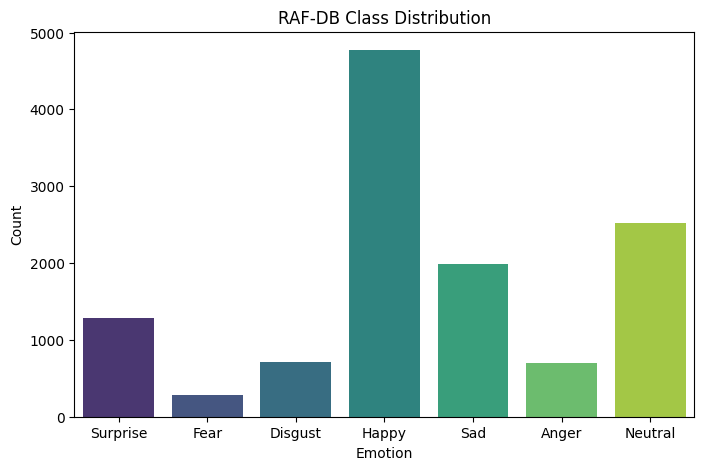

In [7]:
train_counts = {}

for i in range(1,8):
    
    path = os.path.join(TRAIN_DIR,str(i))
    
    train_counts[EMOTIONS[i-1]] = len(os.listdir(path))

df = pd.DataFrame(list(train_counts.items()),columns=["Emotion","Count"])

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Emotion",
    y="Count",
    palette="viridis"
)

plt.title("RAF-DB Class Distribution")

dist_path=os.path.join(OUTPUT_DIR,"class_distribution.png")

plt.savefig(dist_path)

mlflow.log_artifact(dist_path)

plt.show()

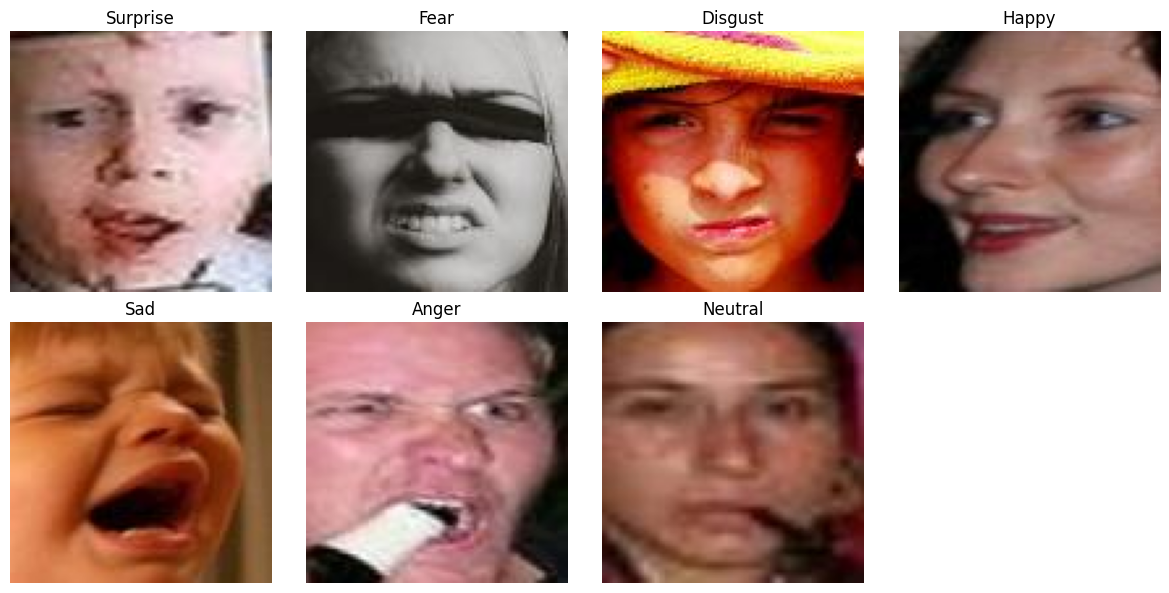

In [8]:
plt.figure(figsize=(12,6))

for i in range(1,8):

    folder = os.path.join(TRAIN_DIR,str(i))
    img_name = os.listdir(folder)[0]

    img = Image.open(os.path.join(folder,img_name))

    plt.subplot(2,4,i)
    plt.imshow(img)
    plt.title(EMOTIONS[i-1])
    plt.axis("off")

sample_path=os.path.join(OUTPUT_DIR,"dataset_samples.png")

plt.savefig(sample_path)

mlflow.log_artifact(sample_path)

plt.tight_layout()
plt.show()

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="categorical",
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode="categorical",
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 12271 files belonging to 7 classes.


I0000 00:00:1772851629.523544      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 3068 files belonging to 7 classes.


In [10]:
data_aug = keras.Sequential([

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2)

])

train_ds = train_ds.map(
    lambda x,y:(data_aug(x),y),
    num_parallel_calls=AUTOTUNE
)

In [11]:
labels=[]

for _,y in train_ds.unbatch():
    labels.append(np.argmax(y.numpy()))

labels=np.array(labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights=dict(enumerate(weights))

mlflow.log_param("class_weights",str(class_weights))

'{0: np.float64(1.3589147286821706), 1: np.float64(6.238434163701068), 2: np.float64(2.4449093444909344), 3: np.float64(0.3673512154233026), 4: np.float64(0.884460141271443), 5: np.float64(2.4865248226950354), 6: np.float64(0.6945324881141046)}'

In [12]:
def se_block(x,ratio=16):

    filters = x.shape[-1]

    se = layers.GlobalAveragePooling2D()(x)

    se = layers.Dense(filters//ratio,activation="relu")(se)

    se = layers.Dense(filters,activation="sigmoid")(se)

    se = layers.Reshape((1,1,filters))(se)

    return layers.multiply([x,se])

In [13]:
def residual_block(x,filters):

    shortcut = x

    x = layers.Conv2D(filters,3,padding="same",activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(filters,3,padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = se_block(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters,1,padding="same")(shortcut)

    x = layers.add([x,shortcut])
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D()(x)

    return x

In [14]:
inputs = keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))

x = layers.Rescaling(1./255)(inputs)

x = residual_block(x,32)
x = residual_block(x,64)
x = residual_block(x,128)
x = residual_block(x,256)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(512,activation="relu")(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(128,activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES,activation="softmax")(x)

model = keras.Model(inputs,outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │         96 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 224, 224,  │        128 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ multiply[0][0],   │
│                     │ 32)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 112, 112,  │     36,928 │ batch_normalizat

 Total params: 1,429,221 (5.45 MB)

 Trainable params: 1,427,301 (5.44 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [15]:
arch_path=os.path.join(OUTPUT_DIR,"architecture.png")

tf.keras.utils.plot_model(
    model,
    to_file=arch_path,
    show_shapes=True,
    show_layer_names=True
)

mlflow.log_artifact(arch_path)

In [16]:
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

optimizer = keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

mlflow.log_params({
    "optimizer":"Adam",
    "learning_rate":1e-4,
    "label_smoothing":0.1
})

In [17]:
callbacks=[

keras.callbacks.ModelCheckpoint(
    os.path.join(OUTPUT_DIR,"best_model.keras"),
    monitor="val_accuracy",
    save_best_only=True
),

keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True
),

keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3
)

]

In [18]:
start=time.time()

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

training_time=time.time()-start

mlflow.log_metric("training_time_seconds",training_time)

Epoch 1/100


I0000 00:00:1772851713.038996     153 service.cc:152] XLA service 0x7f40d8036cd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772851713.039056     153 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772851715.181428     153 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/384 ━━━━━━━━━━━━━━━━━━━━ 2:50:36 27s/step - accuracy: 0.0312 - loss: 2.5473

I0000 00:00:1772851730.787212     153 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


384/384 ━━━━━━━━━━━━━━━━━━━━ 107s 209ms/step - accuracy: 0.1572 - loss: 1.9834 - val_accuracy: 0.3849 - val_loss: 1.7765 - learning_rate: 1.0000e-04
Epoch 2/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 62s 160ms/step - accuracy: 0.2401 - loss: 1.9014 - val_accuracy: 0.3334 - val_loss: 1.8261 - learning_rate: 1.0000e-04
Epoch 3/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 62s 159ms/step - accuracy: 0.2608 - loss: 1.8795 - val_accuracy: 0.2735 - val_loss: 1.8840 - learning_rate: 1.0000e-04
Epoch 4/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 62s 160ms/step - accuracy: 0.2704 - loss: 1.8777 - val_accuracy: 0.3129 - val_loss: 1.8485 - learning_rate: 1.0000e-04
Epoch 5/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 61s 158ms/step - accuracy: 0.2903 - loss: 1.8746 - val_accuracy: 0.3468 - val_loss: 1.7983 - learning_rate: 5.0000e-05
Epoch 6/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 60s 155ms/step - accuracy: 0.3050 - loss: 1.8623 - val_accuracy: 0.3853 - val_loss: 1.7641 - learning_rate: 5.0000e-05
Epoch 7/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 60s 156ms/

In [19]:
for i in range(len(history.history["accuracy"])):

    mlflow.log_metric("train_accuracy",history.history["accuracy"][i],step=i)
    mlflow.log_metric("val_accuracy",history.history["val_accuracy"][i],step=i)
    mlflow.log_metric("train_loss",history.history["loss"][i],step=i)
    mlflow.log_metric("val_loss",history.history["val_loss"][i],step=i)

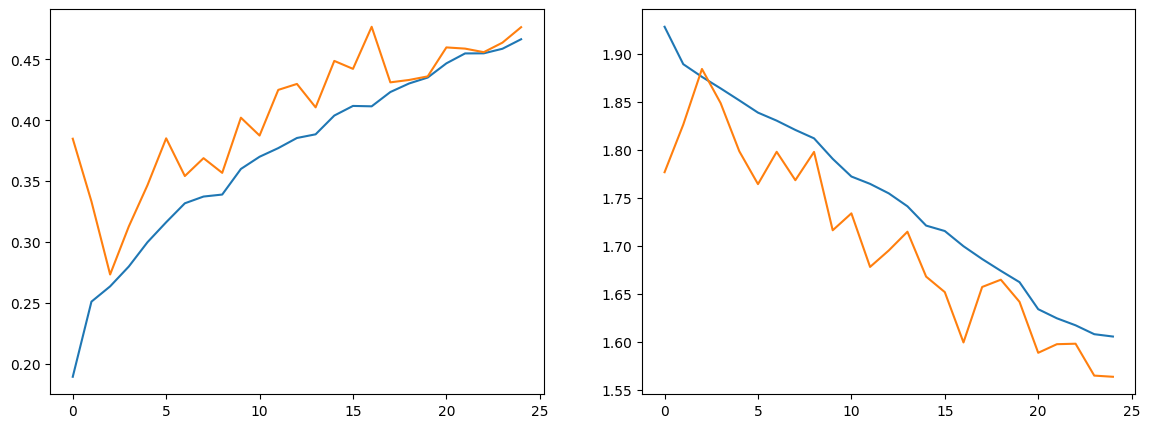

In [20]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

curve_path=os.path.join(OUTPUT_DIR,"training_curves.png")

plt.savefig(curve_path)

mlflow.log_artifact(curve_path)

plt.show()

In [21]:
best_model = keras.models.load_model(
    os.path.join(OUTPUT_DIR,"best_model.keras")
)

mlflow.tensorflow.log_model(best_model,"model")

2026/03/07 03:16:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/07 03:16:22 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [22]:
y_true=[]
y_pred=[]
y_prob=[]

for x,y in test_ds:

    preds = best_model.predict(x)

    y_true.extend(np.argmax(y.numpy(),axis=1))
    y_pred.extend(np.argmax(preds,axis=1))
    y_prob.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━

In [23]:
acc = accuracy_score(y_true,y_pred)

print("Test Accuracy:",acc)

mlflow.log_metric("test_accuracy",acc)

Test Accuracy: 0.476857887874837


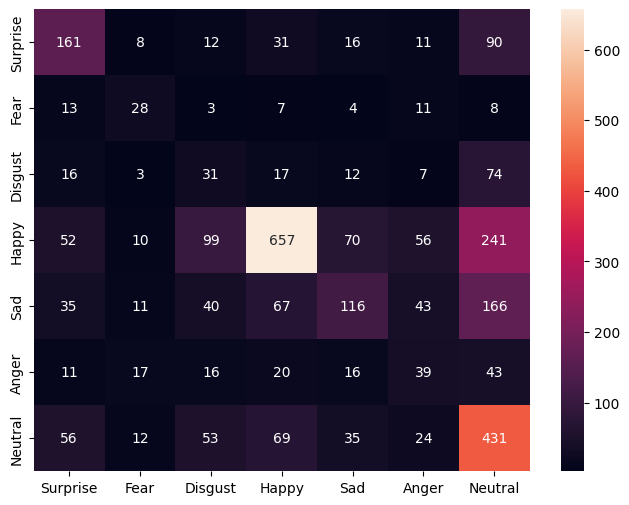

In [24]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=EMOTIONS,
    yticklabels=EMOTIONS
)

cm_path=os.path.join(OUTPUT_DIR,"confusion_matrix.png")

plt.savefig(cm_path)

mlflow.log_artifact(cm_path)

plt.show()

In [25]:
report = classification_report(
    y_true,
    y_pred,
    target_names=EMOTIONS
)

print(report)

report_path=os.path.join(OUTPUT_DIR,"classification_report.txt")

with open(report_path,"w") as f:
    f.write(report)

mlflow.log_artifact(report_path)

              precision    recall  f1-score   support

    Surprise       0.47      0.49      0.48       329
        Fear       0.31      0.38      0.34        74
     Disgust       0.12      0.19      0.15       160
       Happy       0.76      0.55      0.64      1185
         Sad       0.43      0.24      0.31       478
       Anger       0.20      0.24      0.22       162
     Neutral       0.41      0.63      0.50       680

    accuracy                           0.48      3068
   macro avg       0.39      0.39      0.38      3068
weighted avg       0.53      0.48      0.48      3068



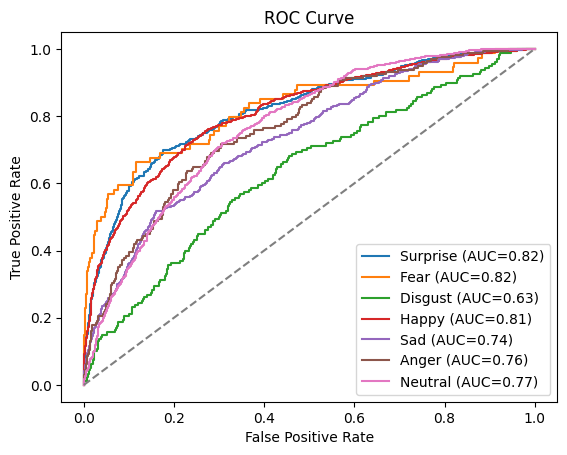

In [26]:
y_true_bin = label_binarize(y_true,classes=range(NUM_CLASSES))
y_prob=np.array(y_prob)

plt.figure()

for i in range(NUM_CLASSES):

    fpr,tpr,_ = roc_curve(y_true_bin[:,i],y_prob[:,i])
    roc_auc = auc(fpr,tpr)

    mlflow.log_metric(f"roc_auc_{EMOTIONS[i]}",roc_auc)

    plt.plot(fpr,tpr,label=f"{EMOTIONS[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

roc_path=os.path.join(OUTPUT_DIR,"roc_curve.png")

plt.savefig(roc_path)

mlflow.log_artifact(roc_path)

plt.show()

In [27]:
mlflow.end_run()

🏃 View run residual_attention_cnn at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/12/runs/3461a031ef4c4b4386153fdb841664c1
🧪 View experiment at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/12
